Remake the heatmaps with the sorted pattern using only significantly tuned cells.
Plot the firing in each tuning curve (the average activity across trials).
For each condition, plot the cells that are signficiant in that condition.

In [97]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

session_names = ["JAL4_3rdSept","JAL4_19thSept","JAL4_28aug","JAL4_11thSept",
    "JAL5_8thSept","JAL5_21stSept",
    "JAL6_28mar", "JAL6_flip4_21mar", "JAL6_flip3_18mar", "JAL6_flip5_25mar", 
    "JAL7_sesh8_9apr", "JAL7_flip5_22mar", "JAL7_flip2_12mar", "JAL7_sesh9_16apr", "JAL7_23apr",
    "JAL8_flip1_25apr", "JAL8_flip2_29apr", "JAL8_flip3_7may",  "JAL8_14may" , "JAL8_flip4_10may"]

In [98]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
"""Load in data from homing/escape analysis"""
%autoreload 2

# compression = ['bird_dist_shelter', 'escape']
compression = ['escape']

c_names = ['shelter_only', 'barrier', 'flipped_barrier']

full_dict = {}
sig_cell_dict = {}
cell_tuning_dict = {}
firing_full = {}
firing_real = {}

for comp in compression:

    full_dict[comp] = {'shelter_only': [],
                        'barrier': [],
                        'flipped_barrier': []}
    
    sesh_names = []
    all_sig_cells = []

    for exp in experiments_objects:

        # load data
        nickname = exp.nick_name + '_' + exp.experiment_date
        sesh_names.append(nickname)
        exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp

        #TODO: change this to not median path once all the processing is redone
        dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
        saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
        data = np.load(saving_file)

        # pull out the paramas
        data_files = data.files
        if 'params_real' in data_files:
            params_real = data['params_real']
            params_shifts = data['params_shifts']
            fr_full = data['fr_full']
            fr_real = data['fr_real']
        else:
            params_real = data["arr_12"]
            params_shifts = data["arr_1"]
            fr_full = data["arr_8"]
            fr_real = data["arr_14"]
        
        # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
        tuning = params_real[:,:,1]
        sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)
        if len(all_sig_cells) == 0:
            all_sig_cells = sig_cells
            cell_tuning = tuning
            fr_full_all = fr_full
            fr_real_all = fr_real
            sesh_vector = np.ones(sig_cells.shape[0])
        else:
            all_sig_cells = np.vstack((all_sig_cells, sig_cells))
            cell_tuning = np.vstack((cell_tuning, tuning))
            sesh_vector = np.hstack((sesh_vector, np.ones(sig_cells.shape[0]) * (sesh_vector[-1]+1)))
            fr_real_all = np.concatenate((fr_real_all, fr_real), axis = 1)
            fr_full_all = np.concatenate((fr_full_all, fr_full), axis = 1)
    
    sig_cell_dict[comp] = all_sig_cells
    cell_tuning_dict[comp] = cell_tuning
    firing_full[comp] = fr_full_all
    firing_real[comp] = fr_real_all

C:\Users\Jasmine\AppData\Local\Temp\ipykernel_6976\3456285007.py:20: RuntimeWarning: invalid value encountered in divide
  display_matrix = this_fr_c/std[:,np.newaxis]
C:\Users\Jasmine\AppData\Local\Temp\ipykernel_6976\3456285007.py:24: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  axs[c, i].imshow(display_matrix, vmin = 0, vmax = 1, cmap="gray_r", aspect="auto", interpolation = "none")


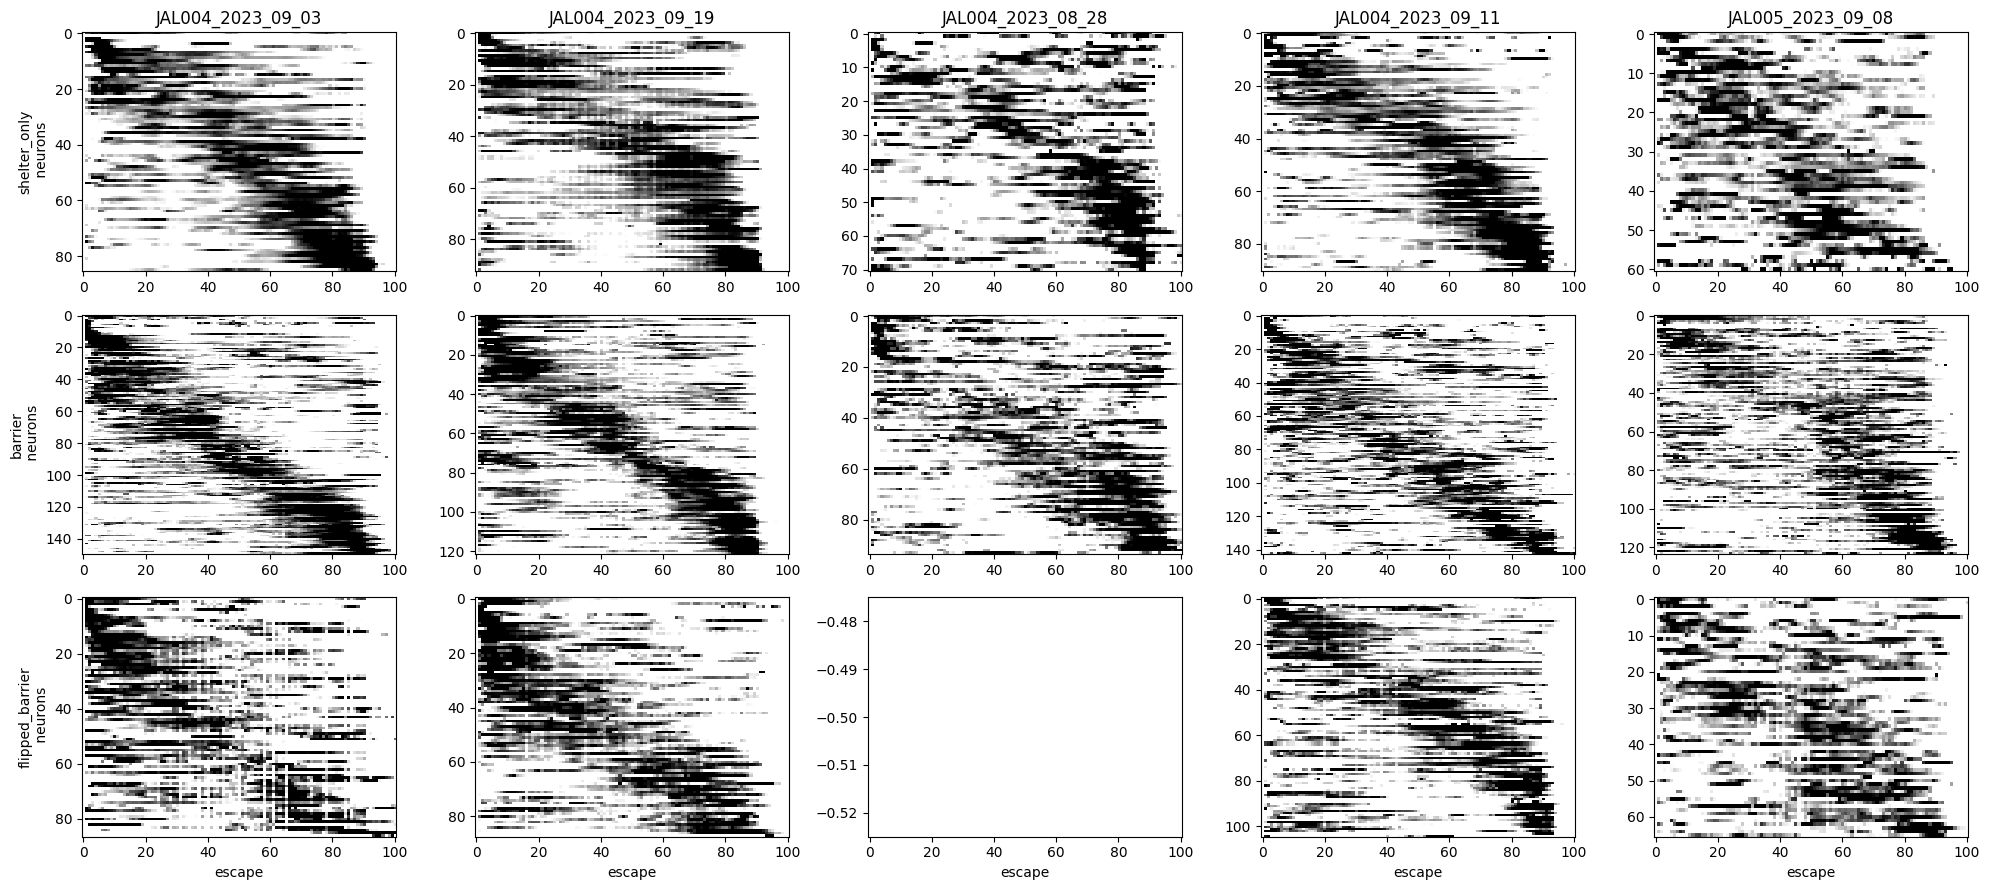

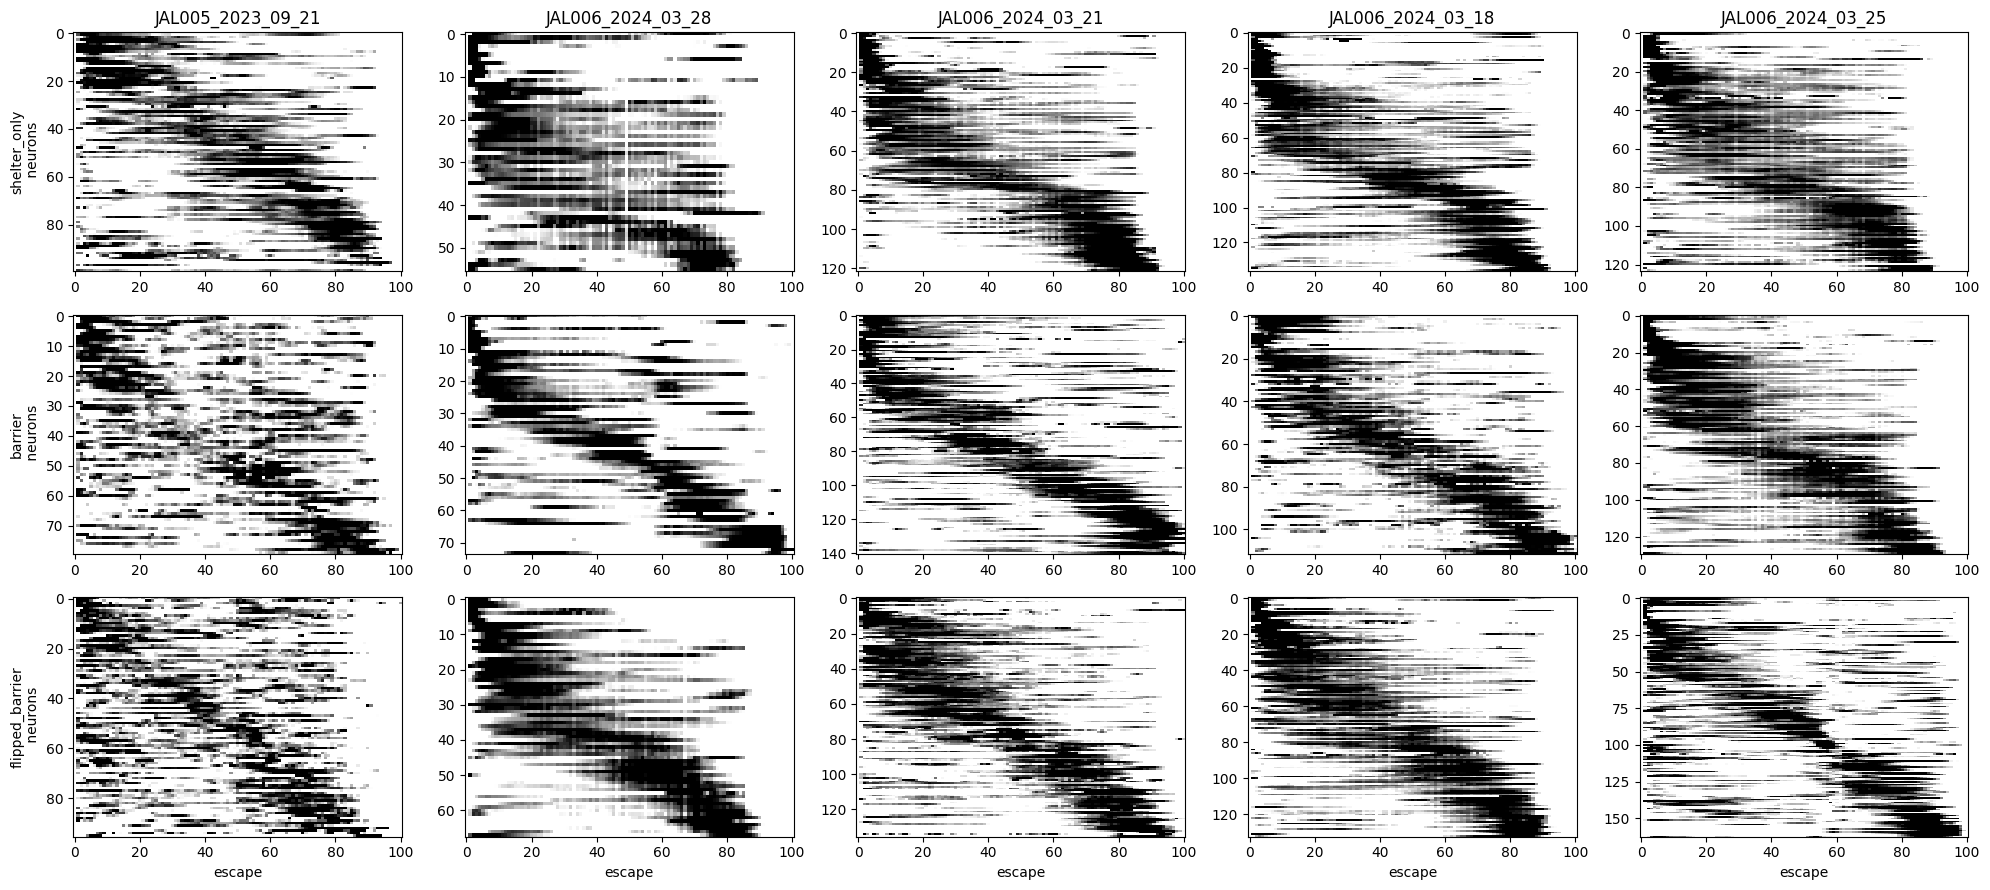

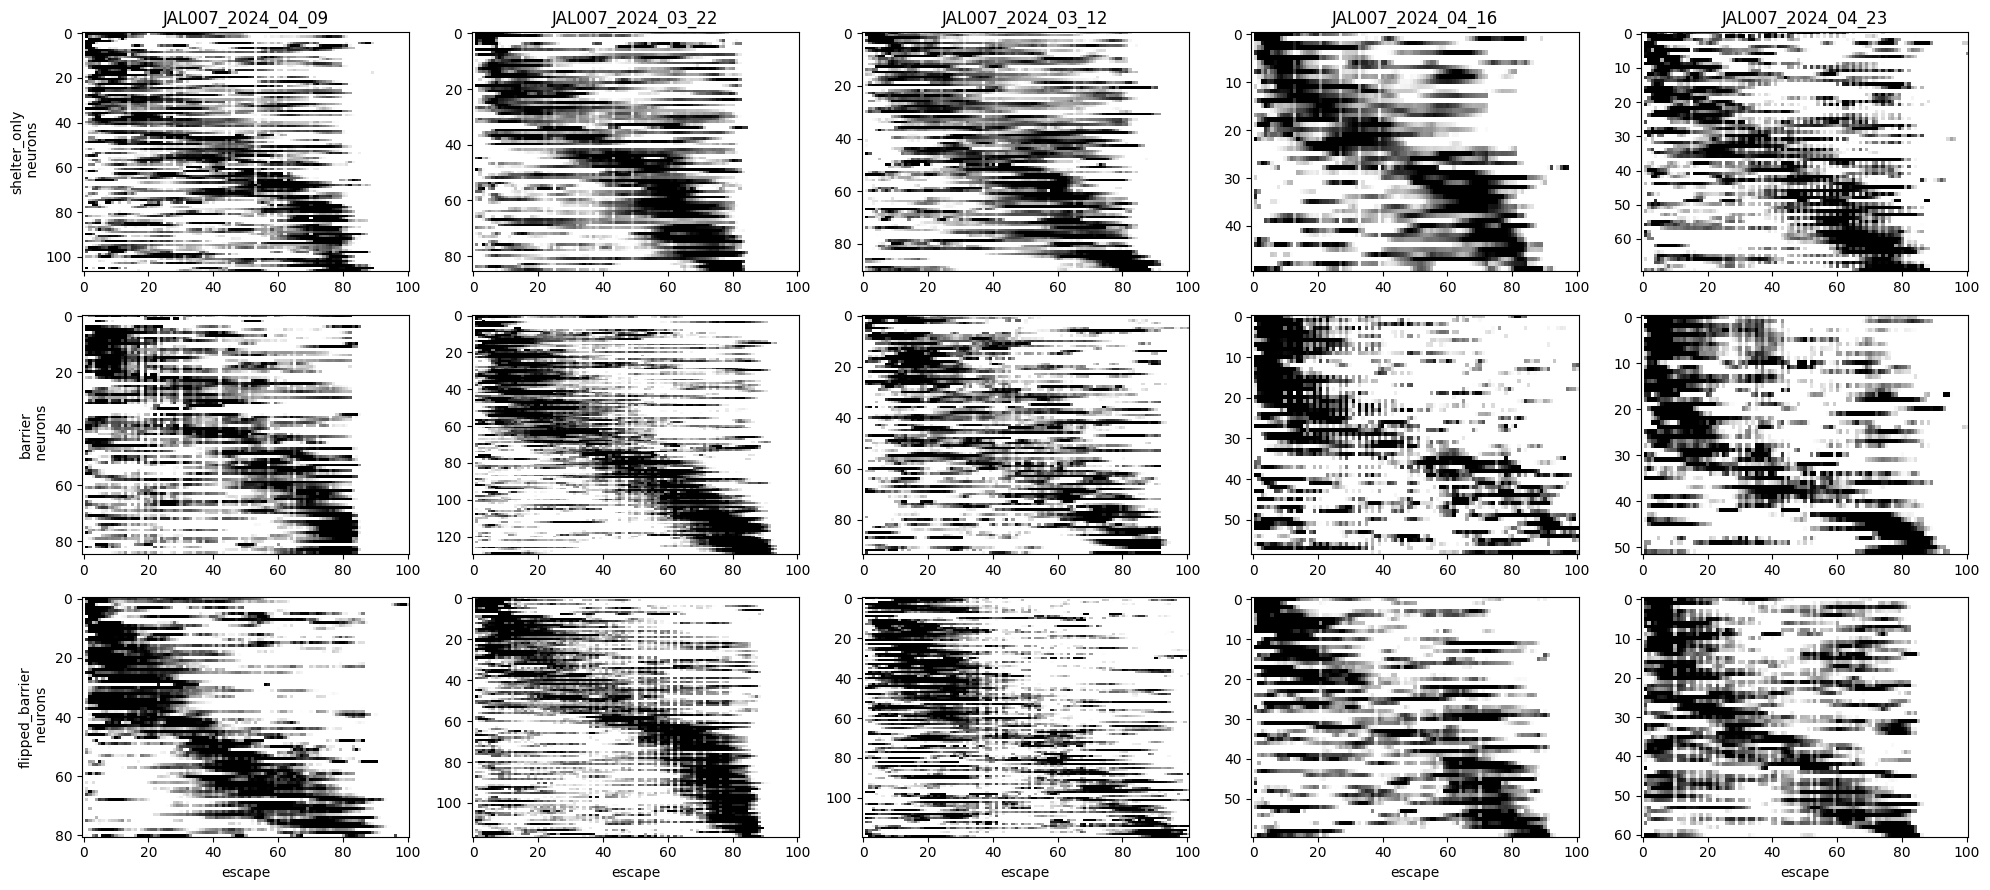

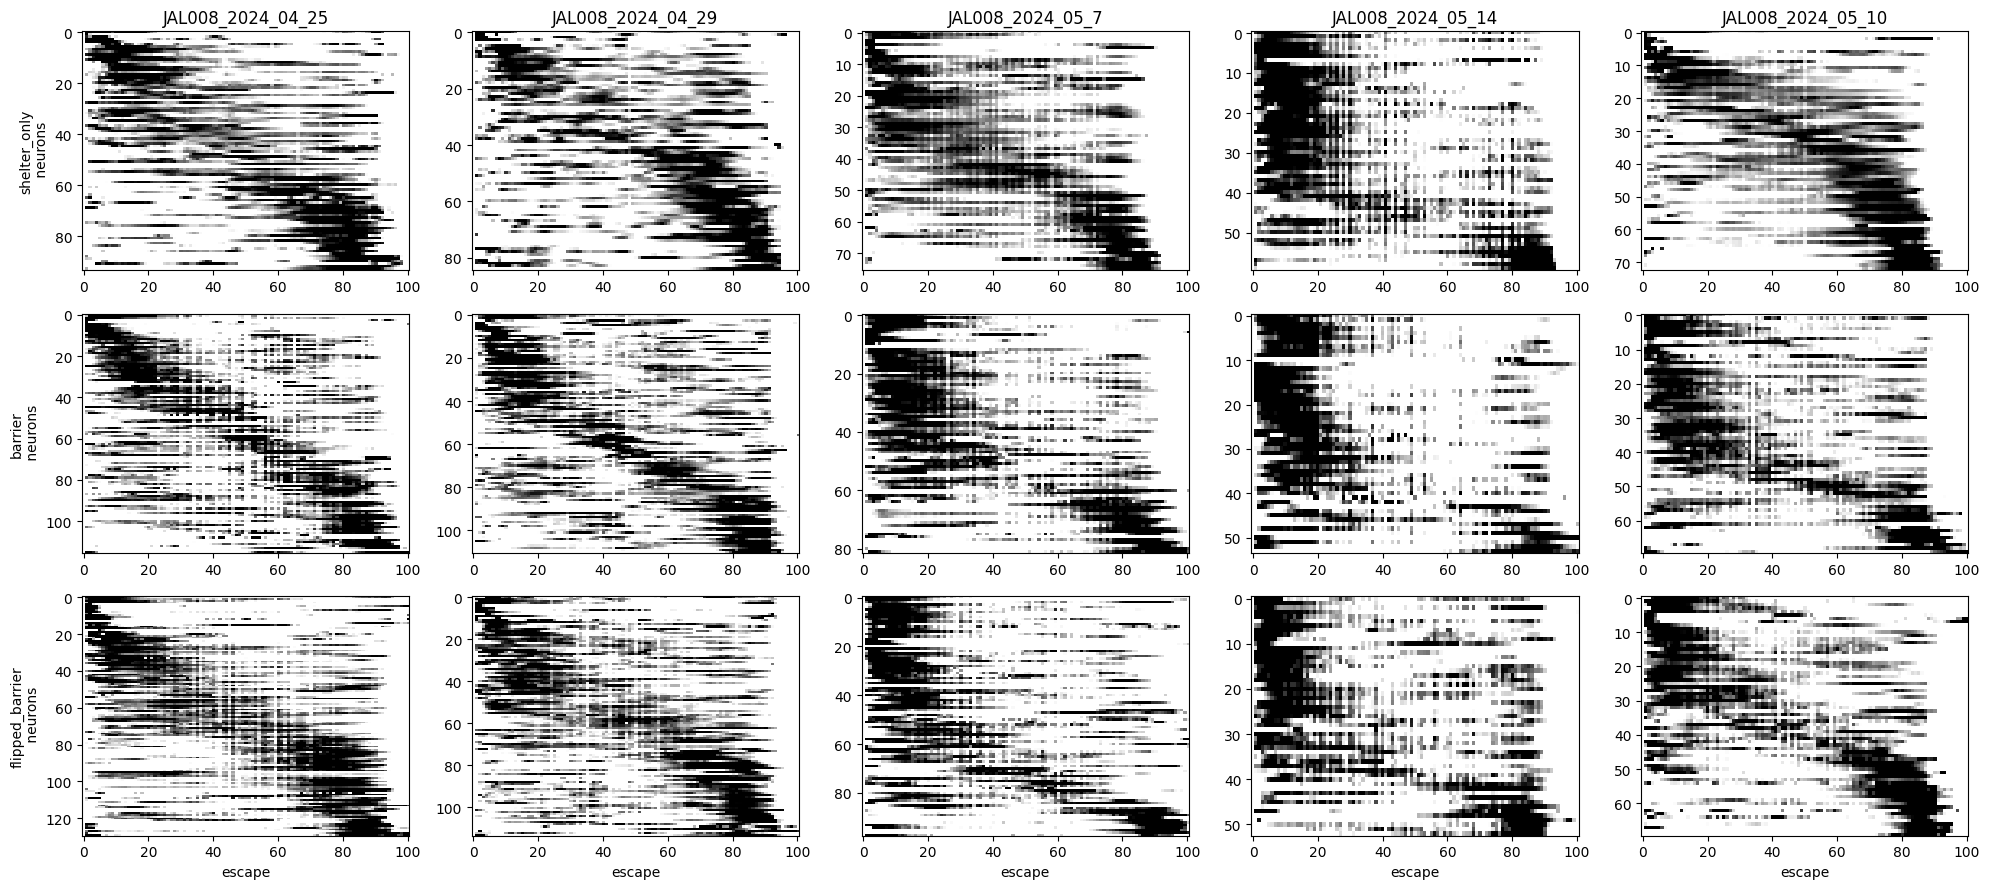

In [103]:
"""Make the plot"""
from scipy.stats import zscore

comp = 'escape'

for idx, sesh in enumerate(np.unique(sesh_vector)):
    if np.remainder(idx, 5) == 0:
        fig, axs = plt.subplots(3, 5, figsize = (20, 9))
    this_fr = firing_full[comp][:,sesh_vector == sesh,:]
    this_sig = sig_cell_dict[comp][sesh_vector == sesh,:]
    # this_sig = np.ones(sig_cell_dict[comp][sesh_vector == sesh,:].shape, dtype = bool) # for now, just plot all cells
    this_tuning = cell_tuning_dict[comp][sesh_vector == sesh,:]
    for c in range(len(c_names)):
        this_fr_c = this_fr[c, this_sig[:, c], :]
        this_tune_c = this_tuning[this_sig[:, c], c]
        this_fr_c = this_fr_c[np.argsort(this_tune_c),:]
        # normalize by dividing by std
        this_fr_c = this_fr_c - np.nanmean(this_fr_c, axis = 1)[:,np.newaxis]
        std = np.nanstd(this_fr_c, axis = 1)
        display_matrix = this_fr_c/std[:,np.newaxis]
        # normalize using zscore
        # display_matrix = zscore(this_fr_c, axis = 0)
        i = np.remainder(idx, 5)
        axs[c, i].imshow(display_matrix, vmin = 0, vmax = 1, cmap="gray_r", aspect="auto", interpolation = "none")
        if i == 0:
            axs[c, i].set_ylabel(c_names[c] + '\n neurons')
        if c == 2:
            axs[c, i].set_xlabel(comp)
        if c == 0:
            axs[c, i].set_title(sesh_names[idx])
    plt.tight_layout()